## Practice Lab 22- Recursive Neural Networks
In this lab we will look at Recursive Neural Networks. \
We will see examples of sequence to vector and sequence to sequence RNN, LSTM and GRU.
Based on Chapter 15 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)


<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice22_RNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

        
# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Exercise 1 - Predictions of time series using different methods
Using the time series generator below, predict future samples by using:
1) Linear model (by using a Neural network)\
2) Recursive Neural network\
3) Deep Recursive Neural network\
At first predict one time sample in output (sequence to vector). \
Then predict 10 time samples in output using sequence to vector first and then sequence to sequence.


We will define a time series generator than can create many instances (time series) at once.

In [2]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

Let us generate 7000 time series, each with 50 samples and an extra sample to predict (later we will predict more than one) 

In [3]:
np.random.seed(42)
n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [4]:
print('batch_size, nsteps, nfeatures)=',X_train.shape, X_valid.shape, X_test.shape)

batch_size, nsteps, nfeatures)= (7000, 50, 1) (2000, 50, 1) (1000, 50, 1)


In [5]:
print(y_train.shape, y_valid.shape, y_test.shape)

(7000, 1) (2000, 1) (1000, 1)


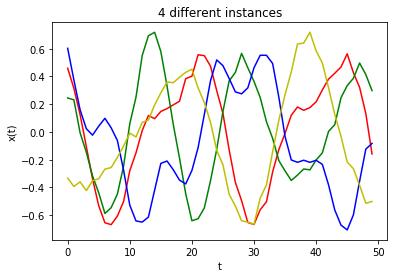

In [6]:
ts=[0,1,10,23]
plt.plot(X_train[ts[0],:,:],'r-')
plt.plot(X_train[ts[1],:,:],'g-')
plt.plot(X_train[ts[2],:,:],'b-')
plt.plot(X_train[ts[3],:,:],'y-')
plt.title('4 different instances')
plt.xlabel('t'),
plt.ylabel('x(t)');

Let us define a function to plot the input and the targets (actual and predicted).

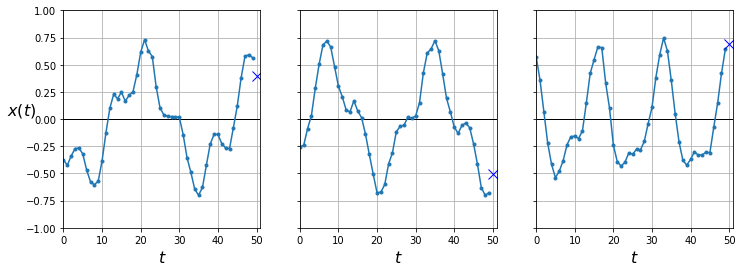

In [7]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    # the cross denotes the target. 
    # if given, the prediction is plot as a circle.
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
# let us plot 3 different instances in separate plots.

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))

plt.show()

The simplest prediction we can do is to repeat the last sample

In [8]:
y_pred_naive=X_valid[:,-1]
print('MSE for naive prediction -->',np.mean(keras.losses.mean_squared_error(y_valid, y_pred_naive)))

MSE for naive prediction --> 0.020211367


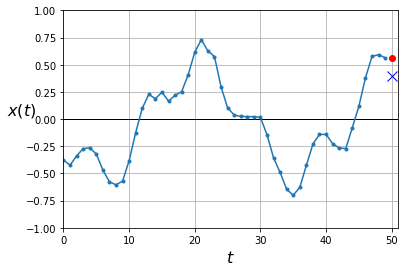

In [9]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred_naive[0, 0])

Before, getting trying RNNs, let us make a linear prediction using what we already know, that is a dense layer

In [10]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 50)                0         
_________________________________________________________________
dense (Dense)                (None, 1)                 51        
Total params: 51
Trainable params: 51
Non-trainable params: 0
_________________________________________________________________


By default, keras puts a linear activation, so the model we are building is just a linear combination (regression).

In [13]:
print(model.layers[1].activation)

<function linear at 0x7f87ec3f8950>


In [14]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 1s 171us/sample - loss: 0.1004 - val_loss: 0.0559
Epoch 2/20
7000/7000 [==============================] - 0s 65us/sample - loss: 0.0386 - val_loss: 0.0269
Epoch 3/20
7000/7000 [==============================] - 0s 64us/sample - loss: 0.0205 - val_loss: 0.0162
Epoch 4/20
7000/7000 [==============================] - 0s 65us/sample - loss: 0.0133 - val_loss: 0.0118
Epoch 5/20
7000/7000 [==============================] - 0s 65us/sample - loss: 0.0104 - val_loss: 0.0098
Epoch 6/20
7000/7000 [==============================] - 0s 65us/sample - loss: 0.0089 - val_loss: 0.0087
Epoch 7/20
7000/7000 [==============================] - 0s 65us/sample - loss: 0.0080 - val_loss: 0.0078
Epoch 8/20
7000/7000 [==============================] - 0s 64us/sample - loss: 0.0073 - val_loss: 0.0071
Epoch 9/20
7000/7000 [==============================] - 0s 67us/sample - loss: 0.0066 - val_loss: 0.0065
Epoch 

Let us compare with the naive approach (copying the last sample)

In [15]:
print('MSE naive prediction',np.mean(keras.losses.mean_squared_error(y_valid, X_valid[:,-1])))
print('MSE error linear model',model.evaluate(X_valid, y_valid))

MSE naive prediction 0.020211367
2000/2000 [==============================] - 0s 33us/sample - loss: 0.0041
MSE error linear model 0.004145486194640398


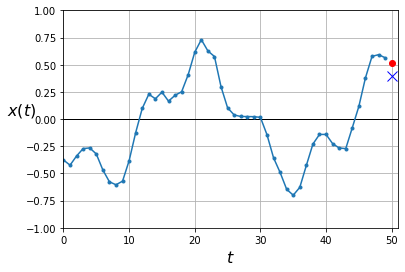

In [16]:
y_pred_DN = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred_DN[0, 0])

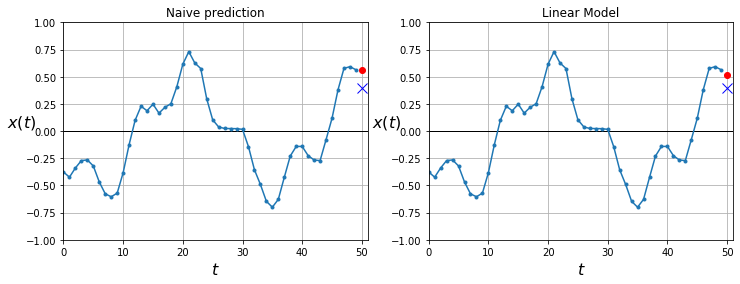

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(12, 4))
col=0
plt.subplot(121),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_naive[col, 0])
plt.title('Naive prediction')
plt.subplot(122),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DN[col, 0])
plt.title('Linear Model');

Now let us use a recursive neural network. Let start with the simplest possible,one layer and one neuron.

In [19]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(lr=0.005)
model.compile(loss="mse", optimizer=optimizer)
model.summary()


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn_1 (SimpleRNN)     (None, 1)                 3         
Total params: 3
Trainable params: 3
Non-trainable params: 0
_________________________________________________________________


In [20]:
history = model.fit(X_train, y_train, epochs=10,validation_data=(X_valid, y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/10
7000/7000 [==============================] - 6s 838us/sample - loss: 0.1003 - val_loss: 0.0457
Epoch 2/10
7000/7000 [==============================] - 5s 701us/sample - loss: 0.0354 - val_loss: 0.0287
Epoch 3/10
7000/7000 [==============================] - 5s 709us/sample - loss: 0.0247 - val_loss: 0.0214
Epoch 4/10
7000/7000 [==============================] - 5s 690us/sample - loss: 0.0195 - val_loss: 0.0174
Epoch 5/10
7000/7000 [==============================] - 5s 707us/sample - loss: 0.0164 - val_loss: 0.0149
Epoch 6/10
7000/7000 [==============================] - 5s 696us/sample - loss: 0.0145 - val_loss: 0.0133
Epoch 7/10
7000/7000 [==============================] - 5s 718us/sample - loss: 0.0132 - val_loss: 0.0123
Epoch 8/10
7000/7000 [==============================] - 5s 714us/sample - loss: 0.0123 - val_loss: 0.0116
Epoch 9/10
7000/7000 [==============================] - 5s 719us/sample - loss: 0.0118 - val_loss: 0.011

That took much longer than the DN. Let us evaluate it:

In [21]:
print('MSE naive prediction',np.mean(keras.losses.mean_squared_error(y_valid, X_valid[:,-1])))
print('MSE error RNN model',model.evaluate(X_valid, y_valid))

MSE naive prediction 0.020211367
2000/2000 [==============================] - 0s 180us/sample - loss: 0.0110
MSE error RNN model 0.010979341611266137


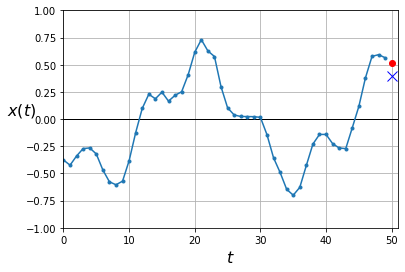

In [22]:
y_pred_RNN = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred_RNN[0, 0])

Text(0.5, 1.0, 'RNN')

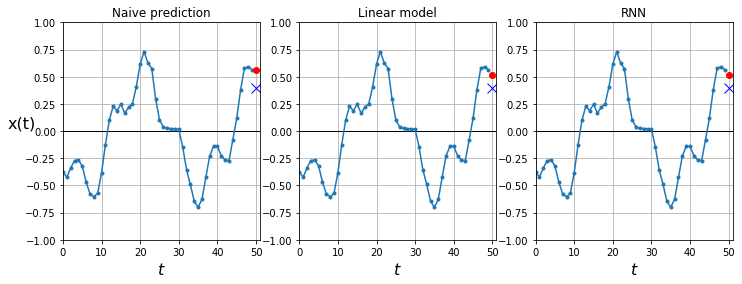

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
col=0
plt.subplot(131),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_naive[col, 0], y_label='x(t)')
plt.title('Naive prediction');
plt.subplot(132),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DN[col, 0], y_label=None)
plt.title('Linear model')
plt.subplot(133),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_RNN[col, 0], y_label=None)
plt.title('RNN')


Disappointly, the DN (linear) prediction is better than the RNN. \
However, we only have 3 parameters for the RNN (one neuron) and 51 for the DN. Let us try more layers.

In [26]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn_2 (SimpleRNN)     (None, None, 20)          440       
_________________________________________________________________
simple_rnn_3 (SimpleRNN)     (None, None, 20)          820       
_________________________________________________________________
simple_rnn_4 (SimpleRNN)     (None, 1)                 22        
Total params: 1,282
Trainable params: 1,282
Non-trainable params: 0
_________________________________________________________________


In [27]:
history = model.fit(X_train, y_train, epochs=10,validation_data=(X_valid, y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/10
7000/7000 [==============================] - 16s 2ms/sample - loss: 0.0559 - val_loss: 0.0087
Epoch 2/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0059 - val_loss: 0.0051
Epoch 3/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0045 - val_loss: 0.0042
Epoch 4/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0041 - val_loss: 0.0038
Epoch 5/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0037 - val_loss: 0.0035
Epoch 6/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0035 - val_loss: 0.0032
Epoch 7/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0034 - val_loss: 0.0031
Epoch 8/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0034 - val_loss: 0.0031
Epoch 9/10
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0032 - val_loss: 0.0033
Epoch 1

In [28]:
print('MSE naive prediction',np.mean(keras.losses.mean_squared_error(y_valid, X_valid[:,-1])))
print('MSE error RNN model',model.evaluate(X_valid, y_valid))

MSE naive prediction 0.020211367
2000/2000 [==============================] - 1s 473us/sample - loss: 0.0033
MSE error RNN model 0.0032893189527094364


In [29]:
y_pred_DRNN = model.predict(X_valid)

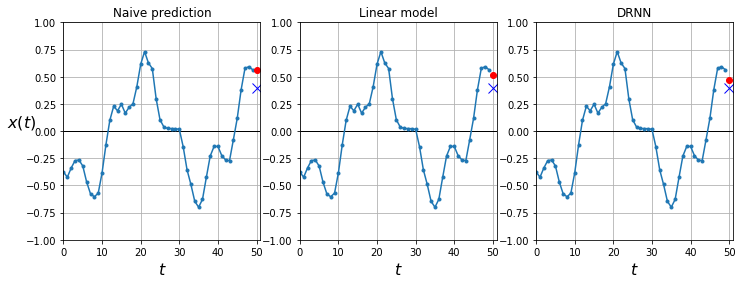

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
col=0
plt.subplot(131),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_naive[col, 0])
plt.title('Naive prediction');
plt.subplot(132),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DN[col, 0], y_label=None)
plt.title('Linear model')
plt.subplot(133),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DRNN[col, 0], y_label=None)
plt.title('DRNN');


The predictions are good, but it is getting quite expensive (a lot more than the DN).\
The cost is not justified in this simple problem. \
But let us consider a more difficult task. We will now try to estimate 10 steps ahead. We could do this in two ways:
1) We predict one sample, put it in, predict the next.\
2) We predict all samples in the gap simultaneously.

For 1) we will use the same network we already trained. We just use it several times.\
First we need to predict a time series for testing (because we need more steps ahead to test).

In [31]:
np.random.seed(43) # not 42, as it would give the first series in the train set

series = generate_time_series(1, n_steps + 10)
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]

In [32]:
print(X_new.shape,Y_new.shape,X.shape,Y_pred.shape)

(1, 50, 1) (1, 10, 1) (1, 60, 1) (1, 10, 1)


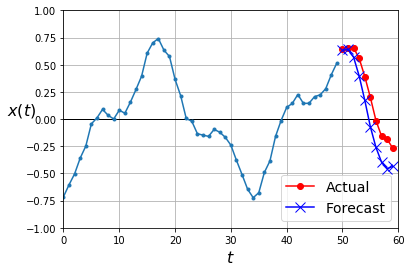

In [33]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    ahead = Y.shape[1]
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()


Now we will do the prediction simultaneously. We need to generate the training dataset again with 10 steps ahead.

In [34]:
#before
print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

(7000, 50, 1) (2000, 50, 1) (1000, 50, 1)
(7000, 1) (2000, 1) (1000, 1)


In [35]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]

In [36]:
print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

(7000, 50, 1) (2000, 50, 1) (1000, 50, 1)
(7000, 1) (2000, 1) (1000, 1)


In [37]:
X = X_valid
for step_ahead in range(10):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:, 0]

In [38]:
print(X_valid.shape,Y_valid.shape,Y_pred.shape)

(2000, 50, 1) (2000, 10) (2000, 10)


In [39]:
Y_naive_pred = Y_valid[:, -1:]
Y_pred_RNN = Y_pred
print('MSE for 10 step predictions naive approach',np.mean(keras.metrics.mean_squared_error(Y_valid, Y_valid[:,-1:])))
print('MSE for 10 step predictions of 10 values',np.mean(keras.metrics.mean_squared_error(Y_valid, Y_pred_RNN)))

MSE for 10 step predictions naive approach 0.22278848
MSE for 10 step predictions of 10 values 0.029392697


The 10 steps RNN is much better than the Naive approach. Let us compare with the DN that works well before

In [40]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=10,
                    validation_data=(X_valid, Y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/10
7000/7000 [==============================] - 1s 105us/sample - loss: 0.1348 - val_loss: 0.0610
Epoch 2/10
7000/7000 [==============================] - 0s 66us/sample - loss: 0.0501 - val_loss: 0.0427
Epoch 3/10
7000/7000 [==============================] - 1s 73us/sample - loss: 0.0388 - val_loss: 0.0356
Epoch 4/10
7000/7000 [==============================] - 0s 68us/sample - loss: 0.0334 - val_loss: 0.0314
Epoch 5/10
7000/7000 [==============================] - 0s 70us/sample - loss: 0.0299 - val_loss: 0.0286
Epoch 6/10
7000/7000 [==============================] - 0s 66us/sample - loss: 0.0275 - val_loss: 0.0264
Epoch 7/10
7000/7000 [==============================] - 0s 66us/sample - loss: 0.0258 - val_loss: 0.0251
Epoch 8/10
7000/7000 [==============================] - 0s 66us/sample - loss: 0.0245 - val_loss: 0.0237
Epoch 9/10
7000/7000 [==============================] - 0s 67us/sample - loss: 0.0235 - val_loss: 0.0229
Epoch 

In [42]:
Y_pred_DN10 = model.predict(X_valid)

In [43]:
print(Y_pred.shape)
print(Y_pred_DN10.shape)

(2000, 10)
(2000, 10)


In [44]:
print('MSE for 10 step predictions Linear Model',np.mean(keras.metrics.mean_squared_error(Y_valid, Y_pred_DN10)))
print('MSE for 10 step predictions of 10 values',np.mean(keras.metrics.mean_squared_error(Y_valid, Y_pred_RNN)))

MSE for 10 step predictions Linear Model 0.022194428
MSE for 10 step predictions of 10 values 0.029392697


The linear model is better.

(2000, 50, 1) (2000, 10) (2000, 10)
50 10
(2000, 50, 1) (2000, 10) (2000, 10)
50 10


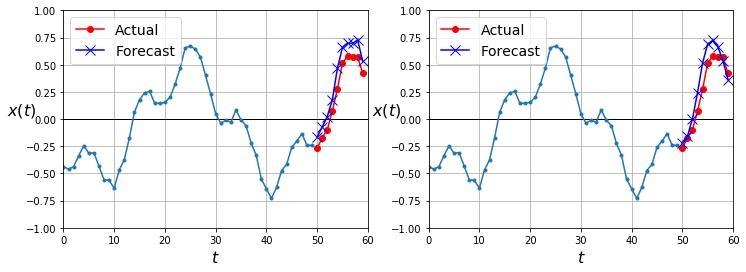

In [45]:
def plot_multiple_forecasts(X, Y, Y_pred):
    print(X.shape, Y.shape, Y_pred.shape)
    n_steps = X.shape[1]    
    ahead = Y.shape[1]
    print(n_steps, ahead)
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

    
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))    
plt.subplot(121),plot_multiple_forecasts(X_valid[:,:,:], Y_valid[:,:], Y_pred_DN10[:,:])
plt.subplot(122),plot_multiple_forecasts(X_valid[:,:,:], Y_valid[:,:], Y_pred_RNN[:,:])

plt.show()

Now let us do the DRNN again but all 10 steps at once, we need to put nsteps neurons in the last layer (like in DN).

In [46]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn_5 (SimpleRNN)     (None, None, 20)          440       
_________________________________________________________________
simple_rnn_6 (SimpleRNN)     (None, 20)                820       
_________________________________________________________________
dense_2 (Dense)              (None, 10)                210       
Total params: 1,470
Trainable params: 1,470
Non-trainable params: 0
_________________________________________________________________


In [47]:
history = model.fit(X_train, Y_train, epochs=10,
                    validation_data=(X_valid, Y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/10
7000/7000 [==============================] - 11s 2ms/sample - loss: 0.0665 - val_loss: 0.0317
Epoch 2/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0268 - val_loss: 0.0221
Epoch 3/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0188 - val_loss: 0.0166
Epoch 4/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0159 - val_loss: 0.0137
Epoch 5/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0138 - val_loss: 0.0127
Epoch 6/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0132 - val_loss: 0.0117
Epoch 7/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0119 - val_loss: 0.0117
Epoch 8/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0115 - val_loss: 0.0119
Epoch 9/10
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0110 - val_loss: 0.0113
Epoch 1

In [48]:
np.random.seed(43) # again we use a different number for random seed to prevent repeating the training series.
# Generate one time serie to predict with 50 steps and 10 steps ahead.
series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, -10:, :]
Y_pred = model.predict(X_new)[..., np.newaxis]

(1, 50, 1) (1, 10, 1) (1, 10, 1)
50 10


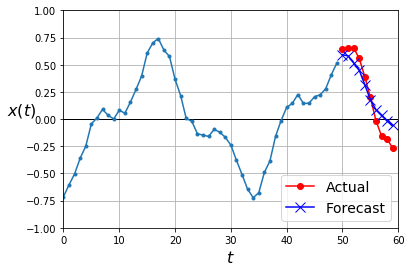

In [49]:
plot_multiple_forecasts(X_new, Y_new, Y_pred)
plt.show()

In [50]:
print('MSE for multistep DNN',model.evaluate(X_valid,Y_valid))

2000/2000 [==============================] - 1s 358us/sample - loss: 0.0097
MSE for multistep DNN 0.009725646067410708


There is one more way to do multistep predictions. We can do sequence to sequence as follows.\
We can evaluate the 10 next steps for each step (instead of the last 10 steps only).\
These values can be used to estimate gradients during training but not for predictions since it is causal model.\
Causal means that the model can see the past not the future (like humans, not counting Nostradamus).

When generating the time series we need to allocate the targets in groups of 10 since the training now will be using 10 samples for each time steps. 

In [51]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

If we look at the shape of the target vector, we see it has an extra dimension of 10 for each of the time steps.

In [52]:
print('y train size is (nbatches, nsteps, nsteps_ahead) =',Y_train.shape)

y train size is (nbatches, nsteps, nsteps_ahead) = (7000, 50, 10)


In [53]:
print('X train is similar as before (nbatches, nsteps, 1) =',X_train.shape)

X train is similar as before (nbatches, nsteps, 1) = (7000, 50, 1)


To predict 10 samples at the end of the series we just used the dense network with 10 neurons.\
Now, however, we need to predict 10 samples for each step. Keras has the TimeDistributed layer to help to do this.\
It needs to pass the Dense layer with 10 neurons (the same as before) but TimeDistributed will used it at each step.\
In addition, we need to use a custom metric that only calculates the error at the end (even when gradients are used for all time steps, we want the error to be measured at the end only).


In [54]:
np.random.seed(42)
tf.random.set_seed(42)
#Time distributed will call the dense layer at each step.
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
#Customized metric to measure error only with the last 10 samples of each batch.
def last_time_step_mse(Y_true, Y_pred):
    return keras.metrics.mean_squared_error(Y_true[:, -1], Y_pred[:, -1])

model.compile(loss="mse", optimizer=keras.optimizers.Adam(lr=0.01), metrics=[last_time_step_mse])
model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
simple_rnn_7 (SimpleRNN)     (None, None, 20)          440       
_________________________________________________________________
simple_rnn_8 (SimpleRNN)     (None, None, 20)          820       
_________________________________________________________________
time_distributed (TimeDistri (None, None, 10)          210       
Total params: 1,470
Trainable params: 1,470
Non-trainable params: 0
_________________________________________________________________


In [55]:
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 12s 2ms/sample - loss: 0.0498 - last_time_step_mse: 0.0388 - val_loss: 0.0416 - val_last_time_step_mse: 0.0321
Epoch 2/20
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0389 - last_time_step_mse: 0.0282 - val_loss: 0.0353 - val_last_time_step_mse: 0.0244
Epoch 3/20
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0324 - last_time_step_mse: 0.0214 - val_loss: 0.0298 - val_last_time_step_mse: 0.0191
Epoch 4/20
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0291 - last_time_step_mse: 0.0177 - val_loss: 0.0285 - val_last_time_step_mse: 0.0174
Epoch 5/20
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0272 - last_time_step_mse: 0.0153 - val_loss: 0.0268 - val_last_time_step_mse: 0.0154
Epoch 6/20
7000/7000 [==============================] - 10s 1ms/sample - loss: 0.0244 - last_time_step_mse: 0.0116 - 

Once again we create a testing time series (one batch, 50 steps + 10 steps ahead).\
We call X the series with the 50 steps only (without the 10), y is the series with the 10 steps ahead.\
The syntaxis in the prediction is a bit strange but it just does a reshaping to take the last 10 steps.\
Remember the TimeDistribute will predict 10 steps for each of the 50 steps, therefore making a matrix (50x10).\
We just want the 10 predictions for the last step.


In [56]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred_DRNN = model.predict(X_new)[:, -1][..., np.newaxis]
print(Y_new.shape,Y_pred_DRNN.shape)

(1, 10, 1) (1, 10, 1)


In [57]:
Y_pred0 = model.predict(X_new)
print(Y_pred0.shape)

(1, 50, 10)


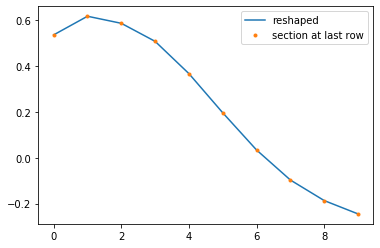

In [58]:
plt.plot(Y_pred_DRNN[0,:,0],label='reshaped')
plt.plot(Y_pred0[0, -1, :],'.',label='section at last row')
plt.legend()

Text(0.5, 1.0, 'predictions in step 40')

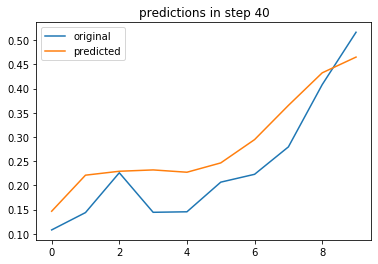

In [61]:
# we don't have values 50-60 in X, so let us plot 40:50
plt.plot(X_new[0,40:50,0],label='original')
plt.plot(Y_pred0[0,39,:],label='predicted')
plt.legend();plt.title('predictions in step 40')

(1, 50, 1) (1, 10, 1) (1, 10, 1)
50 10


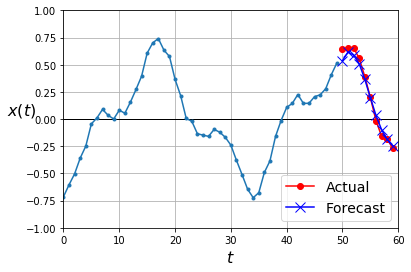

In [62]:
plot_multiple_forecasts(X_new, Y_new, Y_pred_DRNN)
plt.show()

In [63]:
MSE_DRNN=model.evaluate(X_valid, Y_valid)
print(MSE_DRNN)

2000/2000 [==============================] - 1s 366us/sample - loss: 0.0188 - last_time_step_mse: 0.0074
[0.01876381266117096, 0.007429207]


## Exercise 2: Long Short-Term Memory and Gate Recurrent Unit
Let us now use the LSTM, the GRU and compare with the DRNN.\
Everything is similar, except we use the LSTM layer instead of SimpleRNN.\
Also we need the TimeDistributed Layer to predict 10 samples at each time step.

In [64]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 6s 847us/sample - loss: 0.0760 - last_time_step_mse: 0.0615 - val_loss: 0.0554 - val_last_time_step_mse: 0.0372
Epoch 2/20
7000/7000 [==============================] - 2s 258us/sample - loss: 0.0480 - last_time_step_mse: 0.0281 - val_loss: 0.0423 - val_last_time_step_mse: 0.0211
Epoch 3/20
7000/7000 [==============================] - 2s 260us/sample - loss: 0.0390 - last_time_step_mse: 0.0182 - val_loss: 0.0371 - val_last_time_step_mse: 0.0164
Epoch 4/20
7000/7000 [==============================] - 2s 257us/sample - loss: 0.0350 - last_time_step_mse: 0.0151 - val_loss: 0.0335 - val_last_time_step_mse: 0.0143
Epoch 5/20
7000/7000 [==============================] - 2s 258us/sample - loss: 0.0325 - last_time_step_mse: 0.0136 - val_loss: 0.0314 - val_last_time_step_mse: 0.0124
Epoch 6/20
7000/7000 [==============================] - 2s 261us/sample - loss: 0.0308 - last_time_step_mse: 0.0

Notice the time at each iteration was much smaller than before. LSTM can remember more with less effort.

In [65]:
np.random.seed(43)

series = generate_time_series(1, 50 + 10)
X_new, Y_new = series[:, :50, :], series[:, 50:, :]
Y_pred_LSTM = model.predict(X_new)[:, -1][..., np.newaxis]
print(Y_new.shape,Y_pred.shape)

(1, 10, 1) (1, 10, 1)


(1, 50, 1) (1, 10, 1) (1, 10, 1)
50 10


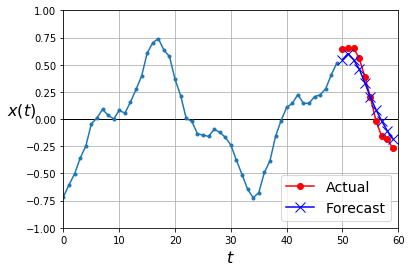

In [66]:
plot_multiple_forecasts(X_new, Y_new, Y_pred_LSTM)
plt.show()

In [67]:
MSE_LSTM=model.evaluate(X_valid, Y_valid)
print(MSE_LSTM)

2000/2000 [==============================] - 0s 138us/sample - loss: 0.0240 - last_time_step_mse: 0.0086
[0.024016652479767798, 0.008551413]


Now the GRU

In [68]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.GRU(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.GRU(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 5s 644us/sample - loss: 0.0742 - last_time_step_mse: 0.0663 - val_loss: 0.0523 - val_last_time_step_mse: 0.0421
Epoch 2/20
7000/7000 [==============================] - 2s 252us/sample - loss: 0.0476 - last_time_step_mse: 0.0367 - val_loss: 0.0441 - val_last_time_step_mse: 0.0327
Epoch 3/20
7000/7000 [==============================] - 2s 247us/sample - loss: 0.0418 - last_time_step_mse: 0.0305 - val_loss: 0.0391 - val_last_time_step_mse: 0.0271
Epoch 4/20
7000/7000 [==============================] - 2s 256us/sample - loss: 0.0373 - last_time_step_mse: 0.0249 - val_loss: 0.0343 - val_last_time_step_mse: 0.0205
Epoch 5/20
7000/7000 [==============================] - 2s 262us/sample - loss: 0.0327 - last_time_step_mse: 0.0179 - val_loss: 0.0313 - val_last_time_step_mse: 0.0158
Epoch 6/20
7000/7000 [==============================] - 2s 244us/sample - loss: 0.0308 - last_time_step_mse: 0.0

This was half the time than the LSTM and much faster than DRNN

In [69]:
Y_pred_GRU = model.predict(X_new)[:, -1][..., np.newaxis]
print(Y_new.shape,Y_pred_GRU.shape)

(1, 10, 1) (1, 10, 1)


(1, 50, 1) (1, 10, 1) (1, 10, 1)
50 10
(1, 50, 1) (1, 10, 1) (1, 10, 1)
50 10
(1, 50, 1) (1, 10, 1) (1, 10, 1)
50 10


(<matplotlib.axes._subplots.AxesSubplot at 0x7f8703b9cfd0>, None)

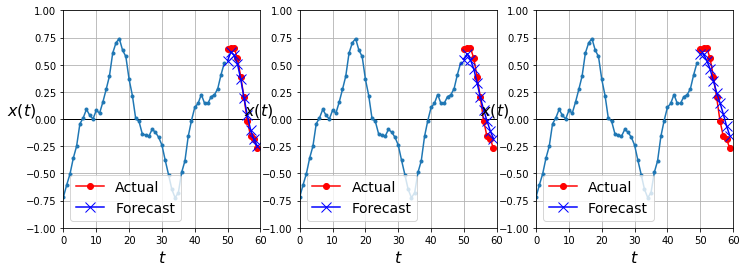

In [71]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
plt.subplot(131),plot_multiple_forecasts(X_new, Y_new, Y_pred_DRNN)
plt.subplot(132),plot_multiple_forecasts(X_new, Y_new, Y_pred_LSTM)
plt.subplot(133),plot_multiple_forecasts(X_new, Y_new, Y_pred_GRU)

In [72]:
MSE_GRU=model.evaluate(X_valid, Y_valid)
print(MSE_GRU)

2000/2000 [==============================] - 0s 131us/sample - loss: 0.0241 - last_time_step_mse: 0.0103
[0.024071006059646606, 0.0102983145]


In [73]:
print(np.round(MSE_DRNN,4), np.round(MSE_LSTM,4), np.round(MSE_GRU,4))

[0.0188 0.0074] [0.024  0.0086] [0.0241 0.0103]
